In [1]:
import csv
import os
import datetime as dt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import torch

import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer.autoguide import AutoNormal
from pyro.optim import Adam

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Exploting and loading data

### Loading data

In [2]:
file_P = os.path.join(os.getcwd(),'Elspotprices2-1.csv')
print("file path: ", file_P)
df_prices = pd.read_csv(file_P)
df_prices["HourUTC"] = pd.to_datetime(df_prices["HourUTC"])
df_prices = df_prices.loc[(df_prices['PriceArea']=="DK2")][["HourUTC","SpotPriceDKK"]]
df_prices = df_prices.loc[df_prices["HourUTC"].dt.year.isin([2019,2020,2021,2022,2023])]
df_prices = df_prices.reset_index(drop=True)
file_P = os.path.join(os.getcwd(),'ProdConData-1.csv')
df_data = pd.read_csv(file_P)
df_data["HourUTC"] = pd.to_datetime(df_data["HourUTC"])
df_data = df_data.loc[df_data["HourUTC"].dt.year.isin([2019,2020,2021,2022,2023])]
df_data = df_data.reset_index(drop=True)


#inspecting the data
df_data.head()

# joining the prices in df_prices to the dataset in df_data
df_merged = pd.merge(df_prices, df_data, on='HourUTC')

# creating a dataset for dk2 only
df_dk2 = df_merged[df_merged['PriceArea']=='DK2']

# defining the training set and the test set according to the assignment
train_s = pd.Timestamp(dt.datetime(2023, 1, 1, 0, 0, 0))
train_e = pd.Timestamp(dt.datetime(2023, 11, 30, 23, 0, 0))
train_data = df_dk2[(df_dk2['HourUTC'] >= train_s) & (df_dk2['HourUTC'] <= train_e)]
test_data  = df_dk2[(df_dk2['HourUTC'] > train_e)]

file path:  /Users/augustpallesen/Documents/GitHub/MBML/August/Elspotprices2-1.csv


### Exploring data

In [3]:
print("Columns of training data: ", train_data.columns)
print("Shape of training data: ", train_data.shape)

Columns of training data:  Index(['HourUTC', 'SpotPriceDKK', 'HourDK', 'PriceArea', 'CentralPowerMWh',
       'LocalPowerMWh', 'CommercialPowerMWh', 'LocalPowerSelfConMWh',
       'OffshoreWindLt100MW_MWh', 'OffshoreWindGe100MW_MWh',
       'OnshoreWindLt50kW_MWh', 'OnshoreWindGe50kW_MWh', 'HydroPowerMWh',
       'SolarPowerLt10kW_MWh', 'SolarPowerGe10Lt40kW_MWh',
       'SolarPowerGe40kW_MWh', 'SolarPowerSelfConMWh', 'UnknownProdMWh',
       'ExchangeNO_MWh', 'ExchangeSE_MWh', 'ExchangeGE_MWh', 'ExchangeNL_MWh',
       'ExchangeGB_MWh', 'ExchangeGreatBelt_MWh', 'GrossConsumptionMWh',
       'GridLossTransmissionMWh', 'GridLossInterconnectorsMWh',
       'GridLossDistributionMWh', 'PowerToHeatMWh'],
      dtype='object')
Shape of training data:  (8016, 29)


Text(0, 0.5, 'SpotPriceDKK')

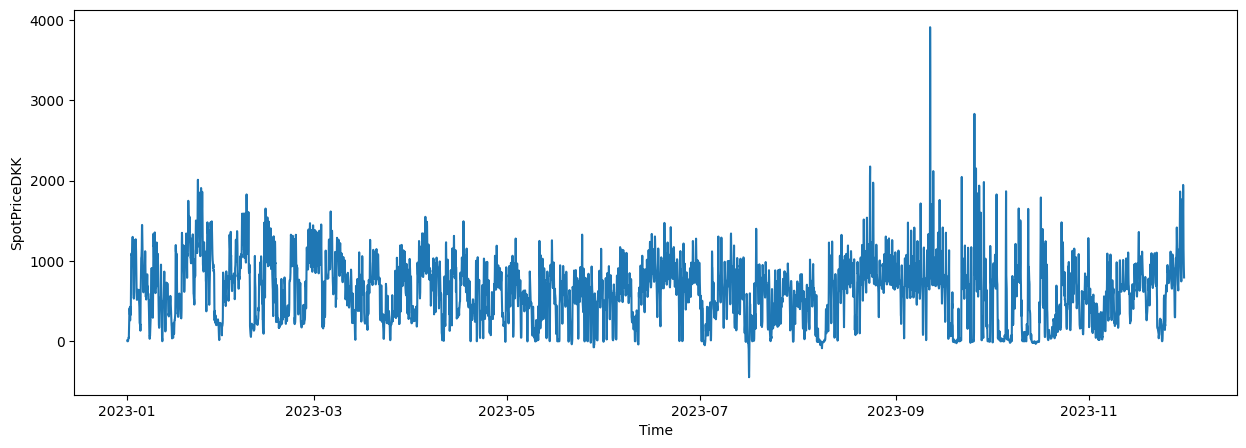

In [5]:
# plotting the data
plt.figure(figsize=(15,5))
plt.plot(train_data['HourUTC'], train_data['SpotPriceDKK'])
plt.xlabel('Time')
plt.ylabel('SpotPriceDKK')


### Picking featueres

As this is not the focus of our assisgment, we don't want to spend a lot of time picking features. So to make it simple we just plot the correlation matrix of all variables that have a correlation stronger than .3 to our target variable.


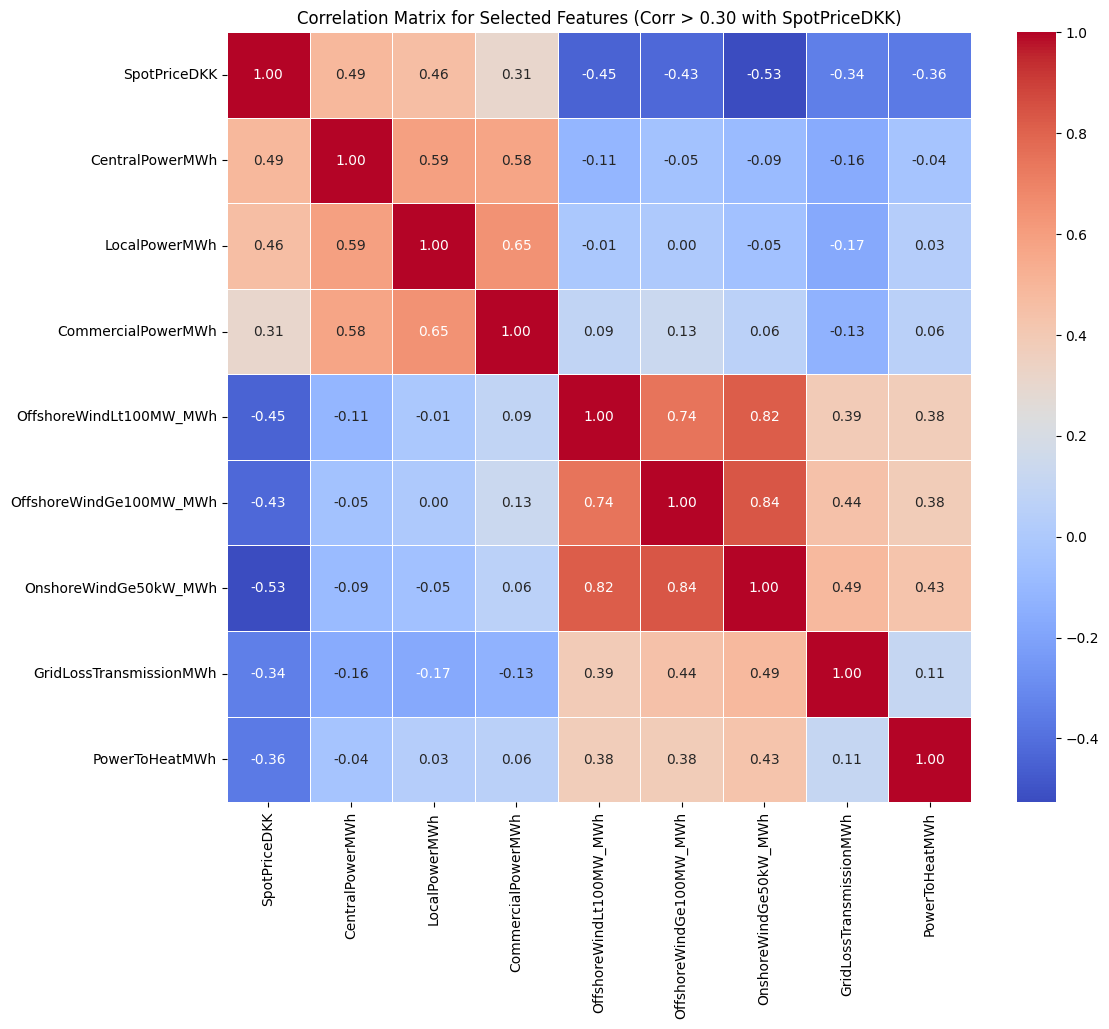

In [6]:
# Make a correlation matrix
# Drop all non-numeric columns
train_data_numeric = train_data.select_dtypes(include=[np.number])
correlation_matrix = train_data_numeric.corr()

# Filter to include only variables with absolute correlation > 0.30 to SpotPriceDKK
correlations_with_target = correlation_matrix['SpotPriceDKK']
selected_vars = correlations_with_target[abs(correlations_with_target) > 0.30].index
correlation_matrix_filtered = correlation_matrix.loc[selected_vars, selected_vars]

# Plot the filtered correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_filtered, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix for Selected Features (Corr > 0.30 with SpotPriceDKK)')
plt.show()


We decide on the following features:
 - OnshoreWindGe50kW_MWh
 - GridLossDistributionMWh,
 - ExchangeSE_MWh

# Models

The idea is to start with a simple model and iterativly make it more and more complex

### prepare data for Gaussian models

In [10]:
########## ---------- Preparing data and normalize ---------- ##########
# Pick features and target
features = ['OnshoreWindGe50kW_MWh', 'GridLossDistributionMWh', 'ExchangeSE_MWh']
time_variables = ['HourUTC']   # optional, see note below
target = 'SpotPriceDKK'

X_train = train_data[features].copy()
y_train = train_data[target].copy()

X_test = test_data[features].copy()
y_test = test_data[target].copy()

# Normalize features
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

# Normilize target
y_mean = y_train.mean()
y_std = y_train.std()
y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std

# Convert to torch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train_scaled.values, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled.values, dtype=torch.float32)

### Simple linear model

The goal is to keep the framework the same for all model st. we can just change the 1 function and reuse the variational inference part.

In [11]:
########## ---------- Making regression model ---------- ##########
def bayesian_linear_regression(X, y=None):
    n_features = X.shape[1]

    # Initialize weights around 0 with std 1, and bias around 0 with std 10 to allow more flexibility
    weights = pyro.sample(
        "weights",
        dist.Normal(torch.zeros(n_features), torch.ones(n_features)).to_event(1)
    )
    bias = pyro.sample("bias", dist.Normal(torch.tensor(0.0), torch.tensor(10.0)))

    # Prior on observation noise
    sigma = pyro.sample("sigma", dist.LogNormal(torch.tensor(0.0), torch.tensor(1.0)))

    mean = X.matmul(weights) + bias

    with pyro.plate("data", X.shape[0]):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)

    return mean


In [12]:
########## ---------- Using variational inference to fit the model ---------- ##########
pyro.clear_param_store()

guide = AutoDiagonalNormal(bayesian_linear_regression)
optimizer = Adam({"lr": 0.03})
svi = SVI(bayesian_linear_regression, guide, optimizer, loss=Trace_ELBO())

num_steps = 5000
for step in range(num_steps):
    loss = svi.step(X_train_t, y_train_t)
    if step % 500 == 0:
        print(f"Step {step} - ELBO loss: {loss:.2f}")


########## ---------- Posterior predictive ---------- ##########
predictive = Predictive(
    bayesian_linear_regression,
    guide=guide,
    num_samples=500,
    return_sites=("obs", "weights", "bias", "sigma")
)

samples = predictive(X_test_t)

# Posterior predictive samples for y on standardized scale
y_pred_samples_scaled = samples["obs"]            # shape: [500, N_test]
y_pred_mean_scaled = y_pred_samples_scaled.mean(0)

# Convert predictions back to original target scale
y_pred_mean = y_pred_mean_scaled.detach().cpu().numpy() * y_std + y_mean
y_test_np = y_test.values




Step 0 - ELBO loss: 28066.65
Step 500 - ELBO loss: 9030.96
Step 1000 - ELBO loss: 9030.16
Step 1500 - ELBO loss: 9046.54
Step 2000 - ELBO loss: 9033.40
Step 2500 - ELBO loss: 9033.82
Step 3000 - ELBO loss: 9033.40
Step 3500 - ELBO loss: 9033.74
Step 4000 - ELBO loss: 9037.07
Step 4500 - ELBO loss: 9040.66


Mean Squared Error: 93100.03347049642
R^2 Score: 0.41600316482448774


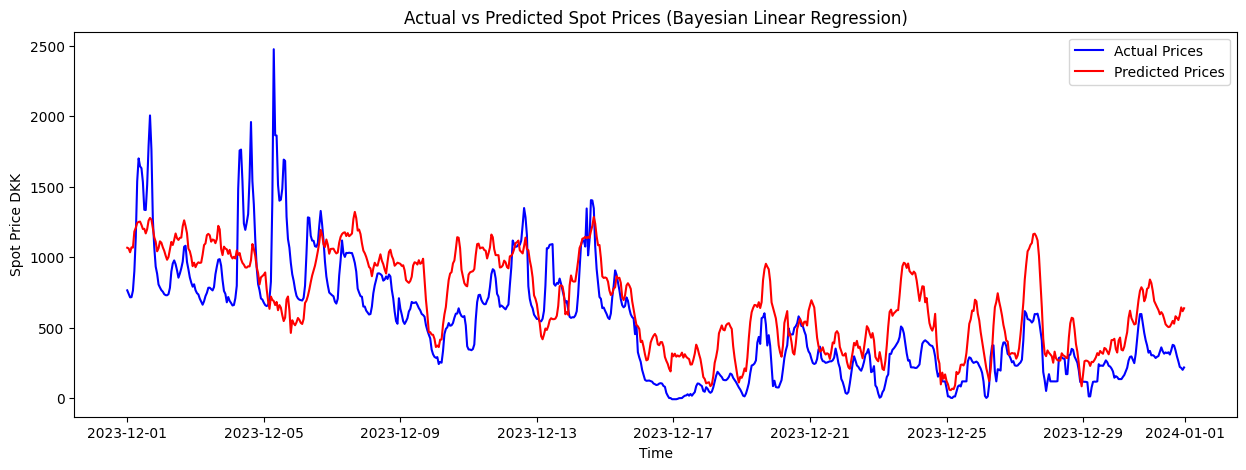

In [13]:
########## ---------- Evaluating the model ---------- ##########
mse = mean_squared_error(y_test_np, y_pred_mean)
r2 = r2_score(y_test_np, y_pred_mean)

print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

# plotting regression results
plt.figure(figsize=(15,5))
plt.plot(test_data['HourUTC'], y_test_np, label='Actual Prices', color='blue')
plt.plot(test_data['HourUTC'], y_pred_mean, label='Predicted Prices', color='red')
plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title('Actual vs Predicted Spot Prices (Bayesian Linear Regression)')
plt.legend()
plt.show()

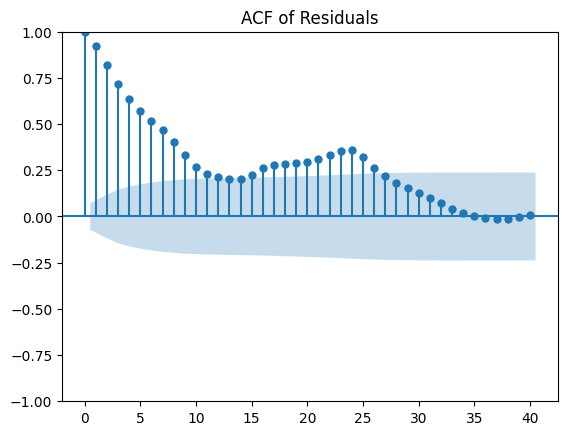

In [28]:
# plot the ACF plot of the residuals
residuals = y_test_np - y_pred_mean
plot_acf(residuals, lags=40)
plt.title('ACF of Residuals')
plt.show()

### autoregressive exogenous input (ARX) model

We cannot use a simple AR model
$$ y_t = \sum_{m=1}^M \left( \beta_m y_t-m \right) + \epsilon $$
Since we have additional features that we would like to model we use the ARX model instead
$$
y_t = \alpha + \sum_{j=1}^{p} \phi_j\, y_{t-j} + \sum_{k=1}^{D} \beta_k\, x_{t,k} + \varepsilon_t,
\qquad t = p+1,\dots,T
$$

In [29]:

pyro.set_rng_seed(42)
pyro.clear_param_store()



########## ---------- Build lagged design matrices ---------- ##########
def make_arx_design(X_t, y_t, lag):
    """
    Build ARX design:
      response at time t
      predictors = [y_{t-1}, ..., y_{t-lag}, X_t]

    Args:
        X_t: torch.Tensor of shape [T, D]
        y_t: torch.Tensor of shape [T]
        lag: int, number of autoregressive lags

    Returns:
        X_design: torch.Tensor of shape [T-lag, lag + D]
        y_target: torch.Tensor of shape [T-lag]
    """
    if lag < 1:
        raise ValueError("lag must be >= 1")

    T = y_t.shape[0]
    if T <= lag:
        raise ValueError("Time series length must be greater than lag")

    y_lags = []
    for t in range(lag, T):
        # order: [y_{t-1}, y_{t-2}, ..., y_{t-lag}]
        lagged_vals = [y_t[t - j] for j in range(1, lag + 1)]
        y_lags.append(torch.stack(lagged_vals))

    y_lags = torch.stack(y_lags)         # [T-lag, lag]
    X_trim = X_t[lag:]                   # [T-lag, D]
    X_design = torch.cat([y_lags, X_trim], dim=1)

    y_target = y_t[lag:]                 # [T-lag]
    return X_design, y_target

########## ---------- Bayesian ARX model in Pyros ---------- ##########
def bayesian_arx_model(X, y=None):
    """
    X: [N, P] design matrix = [lagged y | exogenous features]
    y: [N]
    """
    N, P = X.shape

    # Priors
    intercept = pyro.sample("intercept", dist.Normal(0.0, 1.0))
    weights = pyro.sample("weights", dist.Normal(torch.zeros(P), torch.ones(P)).to_event(1))
    sigma = pyro.sample("sigma", dist.LogNormal(0.0, 0.5))

    mean = intercept + X.matmul(weights)

    with pyro.plate("data", N):
        pyro.sample("obs", dist.Normal(mean, sigma), obs=y)


########## ---------- Train with variational inference ---------- ##########
def fit_bayesian_arx(X_train_t, y_train_t, lag=3, lr=0.02, num_steps=3000):
    X_design, y_target = make_arx_design(X_train_t, y_train_t, lag)

    guide = AutoNormal(bayesian_arx_model)
    optim = Adam({"lr": lr})
    svi = SVI(bayesian_arx_model, guide, optim, loss=Trace_ELBO())

    losses = []
    for step in range(num_steps):
        loss = svi.step(X_design, y_target)
        losses.append(loss)

        if step % 500 == 0:
            print(f"Step {step:4d}  ELBO loss = {loss:.2f}")

    return {
        "guide": guide,
        "losses": losses,
        "lag": lag,
        "X_design": X_design,
        "y_target": y_target,
    }


########## ---------- Posterior prediction on a prepared design matrix ---------- ##########
def posterior_predict(guide, X_design, num_samples=500):
    predictive = Predictive(
        bayesian_arx_model,
        guide=guide,
        num_samples=num_samples,
        return_sites=("obs", "intercept", "weights", "sigma"),
    )
    samples = predictive(X_design)

    y_samples = samples["obs"]                  # [S, N]
    y_mean = y_samples.mean(0)                  # [N]
    y_std = y_samples.std(0)                    # [N]

    return {
        "y_samples": y_samples,
        "y_mean": y_mean,
        "y_std": y_std,
        "posterior_samples": samples,
    }

########## ---------- Prepare train/test designs with same lag ---------- ##########
def prepare_train_test_arx(X_train_t, y_train_t, X_test_t, y_test_t, lag):
    X_train_design, y_train_target = make_arx_design(X_train_t, y_train_t, lag)
    X_test_design, y_test_target = make_arx_design(X_test_t, y_test_t, lag)
    return X_train_design, y_train_target, X_test_design, y_test_target


########## ---------- Utility: inverse-transform target back to original units ---------- ##########
def invert_target_scaling(y_scaled, y_mean, y_std):
    return y_scaled * y_std + y_mean


########## ---------- Example run ---------- ##########
lag = 11   # <-- change this to control memory / number of lags

X_train_design, y_train_target, X_test_design, y_test_target = prepare_train_test_arx(
    X_train_t, y_train_t, X_test_t, y_test_t, lag=lag
)

fit_result = fit_bayesian_arx(X_train_t, y_train_t, lag=lag, lr=0.02, num_steps=3000)
guide = fit_result["guide"]

pred_test = posterior_predict(guide, X_test_design, num_samples=1000)

# Predictions in scaled space
y_test_pred_mean_scaled = pred_test["y_mean"]
y_test_pred_std_scaled = pred_test["y_std"]

# Back to original target scale
y_test_pred_mean = invert_target_scaling(y_test_pred_mean_scaled, y_mean, y_std)
y_test_pred_std = y_test_pred_std_scaled * y_std
y_test_true = invert_target_scaling(y_test_target, y_mean, y_std)

rmse = torch.sqrt(torch.mean((y_test_pred_mean - y_test_true) ** 2))
mae = torch.mean(torch.abs(y_test_pred_mean - y_test_true))

print(f"\nTest RMSE: {rmse.item():.4f}")
print(f"Test MAE : {mae.item():.4f}")

Step    0  ELBO loss = 10680.29
Step  500  ELBO loss = 1893.11
Step 1000  ELBO loss = 1825.38
Step 1500  ELBO loss = 2075.61
Step 2000  ELBO loss = 1907.11
Step 2500  ELBO loss = 1816.35

Test RMSE: 98.0072
Test MAE : 63.6074


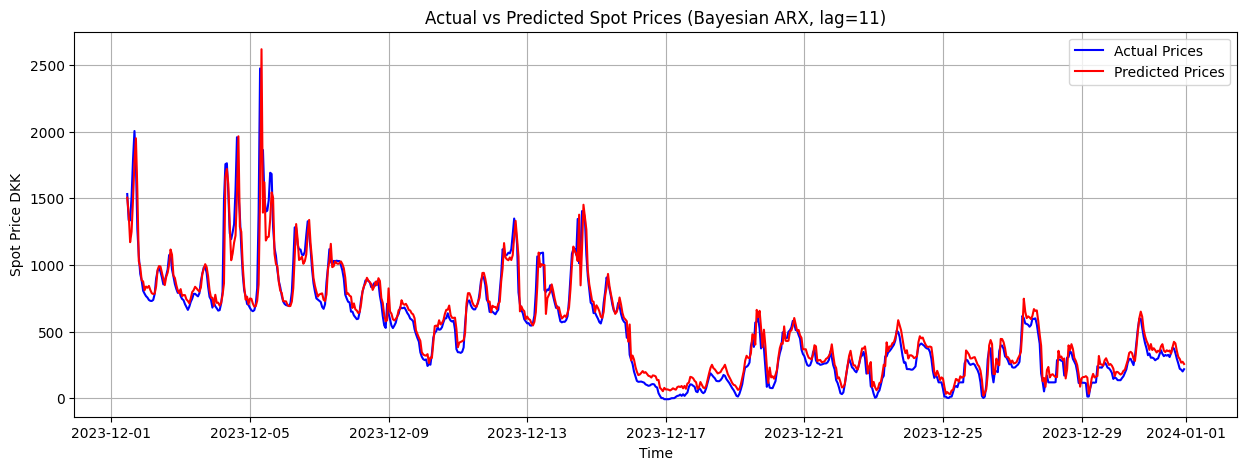

In [30]:
time_test = test_data['HourUTC'].iloc[lag:].reset_index(drop=True)

plt.figure(figsize=(15,5))
plt.plot(time_test, y_test_true.numpy(), label='Actual Prices', color='blue')
plt.plot(time_test, y_test_pred_mean.detach().numpy(), label='Predicted Prices', color='red')

plt.xlabel('Time')
plt.ylabel('Spot Price DKK')
plt.title(f'Actual vs Predicted Spot Prices (Bayesian ARX, lag={lag})')
plt.legend()
plt.grid(True)
plt.show()

### Markov Model

A simple Hidden Markov Model (HMM) captures the idea that electricity prices are generated from a small number of latent **market regimes** (e.g. low / medium / high). The hidden state $z_t \in \{1,\dots,K\}$ evolves as a first-order Markov chain:

$$
z_t \mid z_{t-1} \sim \text{Categorical}(A_{z_{t-1},\cdot})
$$

and each regime produces prices from its own Gaussian emission:

$$
y_t \mid z_t \sim \mathcal{N}(\mu_{z_t},\,\sigma_{z_t}^2)
$$

We marginalise over the discrete states using Pyro's `DiscreteHMM` and fit the continuous parameters $\mu, \sigma, A, \pi$ with SVI.

In [14]:
########## ---------- HMM model definition ---------- ##########
from pyro.distributions import DiscreteHMM

K = 3   # number of hidden price regimes

def simple_markov_model(y_obs=None, T=None):
    if y_obs is not None:
        T = y_obs.shape[0]

    # Prior on initial state logits
    initial_logits = pyro.sample(
        "initial_logits", dist.Normal(torch.zeros(K), torch.ones(K)).to_event(1)
    )

    # Prior on transition matrix logits  [K, K]: row i = transitions FROM state i
    transition_logits = pyro.sample(
        "transition_logits", dist.Normal(torch.zeros(K, K), torch.ones(K, K)).to_event(2)
    )

    # Per-state emission parameters
    emission_loc = pyro.sample(
        "emission_loc", dist.Normal(torch.zeros(K), 2.0 * torch.ones(K)).to_event(1)
    )
    emission_scale = pyro.sample(
        "emission_scale", dist.LogNormal(torch.zeros(K), 0.5 * torch.ones(K)).to_event(1)
    )

    # Observation distribution conditioned on state  (batch_shape = [K])
    obs_dist = dist.Normal(emission_loc, emission_scale)

    hmm = DiscreteHMM(initial_logits, transition_logits, obs_dist)
    pyro.sample("y", hmm, obs=y_obs)


Step    0  ELBO loss = 11578.42
Step  500  ELBO loss = 6475.82
Step 1000  ELBO loss = 6477.66
Step 1500  ELBO loss = 6474.20
Step 2000  ELBO loss = 6467.86
Step 2500  ELBO loss = 6478.57


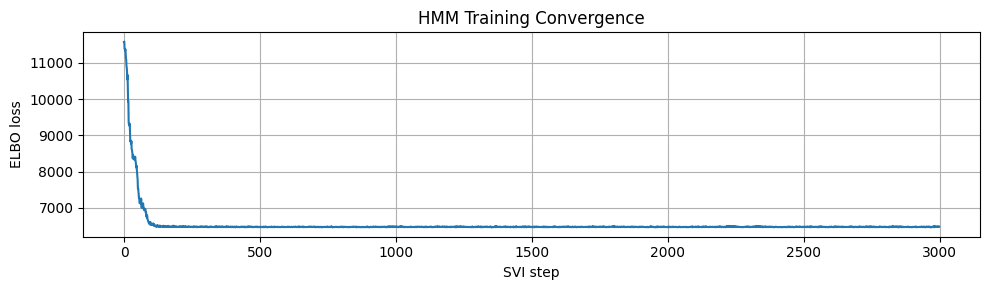

In [15]:
########## ---------- Fit with SVI ---------- ##########
pyro.clear_param_store()
pyro.set_rng_seed(42)

guide_hmm = AutoDiagonalNormal(simple_markov_model)
optimizer_hmm = Adam({"lr": 0.05})
svi_hmm = SVI(simple_markov_model, guide_hmm, optimizer_hmm, loss=Trace_ELBO())

num_steps_hmm = 3000
losses_hmm = []
for step in range(num_steps_hmm):
    loss = svi_hmm.step(y_train_t)
    losses_hmm.append(loss)
    if step % 500 == 0:
        print(f"Step {step:4d}  ELBO loss = {loss:.2f}")

plt.figure(figsize=(10, 3))
plt.plot(losses_hmm)
plt.xlabel("SVI step")
plt.ylabel("ELBO loss")
plt.title("HMM Training Convergence")
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
########## ---------- Extract posterior mean parameters ---------- ##########
predictive_hmm = Predictive(
    simple_markov_model, guide=guide_hmm, num_samples=500,
    return_sites=["initial_logits", "transition_logits", "emission_loc", "emission_scale"]
)
post_samples = predictive_hmm(y_obs=y_train_t)

init_logits_map  = post_samples["initial_logits"].mean(0).detach()
trans_logits_map = post_samples["transition_logits"].mean(0).detach()
emit_loc_map     = post_samples["emission_loc"].mean(0).detach()
emit_scale_map   = post_samples["emission_scale"].mean(0).detach()

# Sort states by ascending emission mean for interpretability
order = emit_loc_map.argsort()
emit_loc_map     = emit_loc_map[order]
emit_scale_map   = emit_scale_map[order]
init_logits_map  = init_logits_map[order]
trans_logits_map = trans_logits_map[order][:, order]

print("Emission means (scaled):", emit_loc_map.numpy().round(3))
print("Emission stds  (scaled):", emit_scale_map.numpy().round(3))
trans_probs = torch.softmax(trans_logits_map, dim=-1)
print("Transition matrix (rows = from-state, cols = to-state):")
print(trans_probs.numpy().round(3))


########## ---------- Forward-filter one-step-ahead predictions ---------- ##########
def forward_filter_predict(y, initial_logits, transition_logits, emission_loc, emission_scale):
    """
    One-step-ahead predictions: at each t, predict E[y_t | y_{1:t-1}]
    using the predictive state distribution p(z_t | y_{1:t-1}).
    """
    T = y.shape[0]
    log_pi = torch.log_softmax(initial_logits, dim=-1)   # [K]
    log_A  = torch.log_softmax(transition_logits, dim=-1) # [K, K]

    def log_emit(t):
        # log p(y_t | z_t = k) for all k  ->  [K]
        return dist.Normal(emission_loc, emission_scale).log_prob(y[t])

    predictions = []

    # t = 0: predicted from prior
    pred_probs = torch.softmax(log_pi, dim=-1)
    predictions.append((pred_probs * emission_loc).sum())

    # filter at t = 0
    log_alpha = log_pi + log_emit(0)
    log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)

    for t in range(1, T):
        # Predict: p(z_t | y_{1:t-1})  [K]
        # log_pred[j] = logsumexp_i ( log_alpha[i] + log_A[i,j] )
        log_pred = torch.logsumexp(log_alpha.unsqueeze(-1) + log_A, dim=0)
        log_pred = log_pred - torch.logsumexp(log_pred, dim=-1, keepdim=True)
        pred_probs = torch.softmax(log_pred, dim=-1)
        predictions.append((pred_probs * emission_loc).sum())

        # Update filter: p(z_t | y_{1:t})
        log_alpha = log_pred + log_emit(t)
        log_alpha = log_alpha - torch.logsumexp(log_alpha, dim=-1, keepdim=True)

    return torch.stack(predictions)  # [T]


y_pred_scaled_hmm = forward_filter_predict(
    y_test_t, init_logits_map, trans_logits_map, emit_loc_map, emit_scale_map
)

# Back to original scale
y_pred_hmm = y_pred_scaled_hmm.detach().numpy() * y_std + y_mean
y_test_np2 = y_test.values

rmse_hmm = float(((y_pred_hmm - y_test_np2) ** 2).mean() ** 0.5)
mae_hmm  = float(abs(y_pred_hmm - y_test_np2).mean())

print(f"\nTest RMSE: {rmse_hmm:.4f}")
print(f"Test MAE : {mae_hmm:.4f}")


Emission means (scaled): [-1.115  0.131  1.201]
Emission stds  (scaled): [0.407 0.332 0.646]
Transition matrix (rows = from-state, cols = to-state):
[[0.939 0.055 0.006]
 [0.049 0.879 0.072]
 [0.002 0.131 0.867]]

Test RMSE: 187.8871
Test MAE : 125.4029


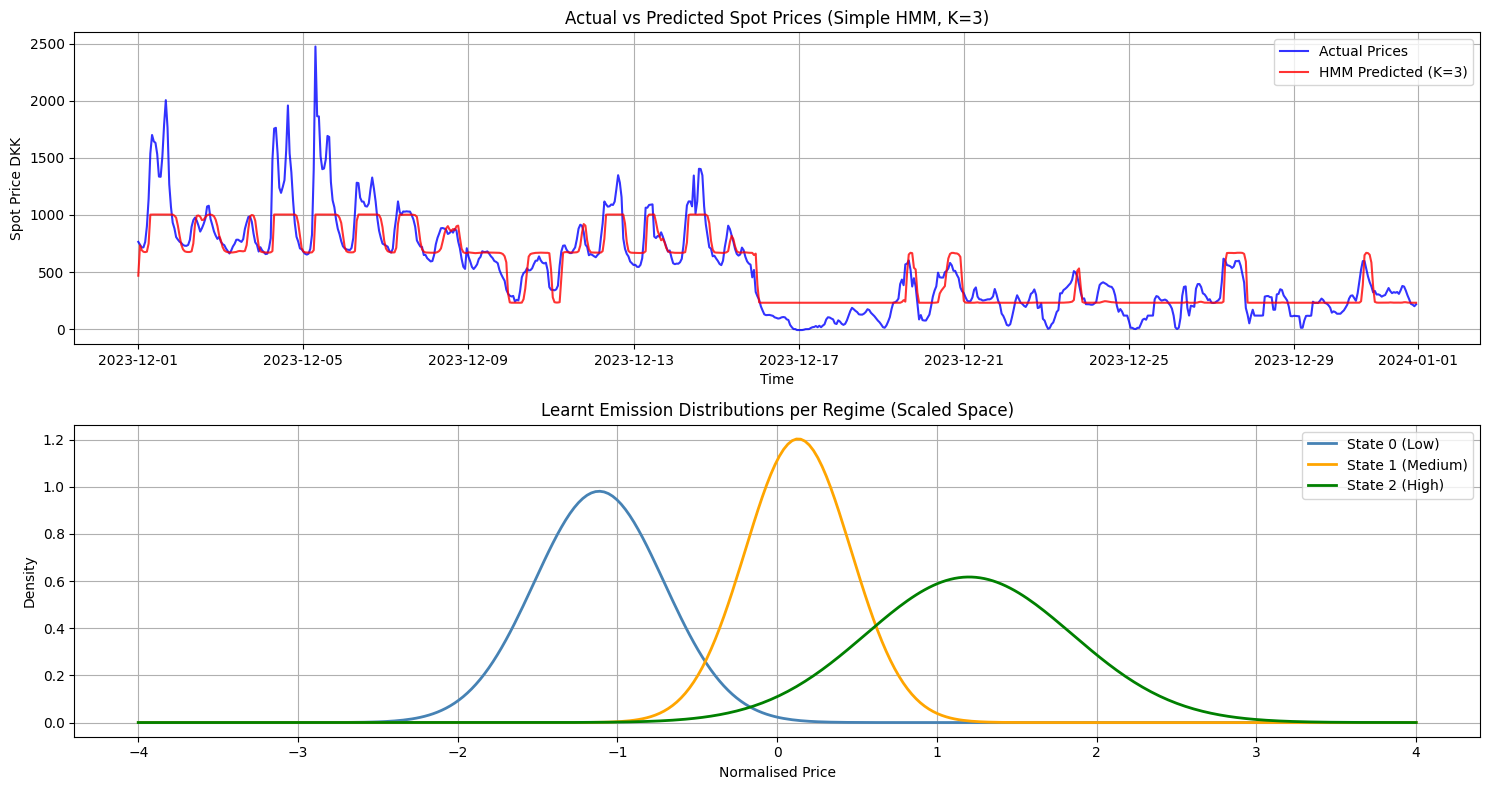

In [17]:
########## ---------- Visualize predictions ---------- ##########
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Actual vs predicted prices
axes[0].plot(test_data['HourUTC'], y_test_np2, label='Actual Prices', color='blue', alpha=0.8)
axes[0].plot(test_data['HourUTC'], y_pred_hmm, label=f'HMM Predicted (K={K})', color='red', alpha=0.8)
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Spot Price DKK')
axes[0].set_title(f'Actual vs Predicted Spot Prices (Simple HMM, K={K})')
axes[0].legend()
axes[0].grid(True)

# Emission distributions
x_grid = torch.linspace(-4, 4, 300)
regime_names = ['Low', 'Medium', 'High']
colors = ['steelblue', 'orange', 'green']
for k in range(K):
    pdf = dist.Normal(emit_loc_map[k], emit_scale_map[k]).log_prob(x_grid).exp().numpy()
    label = f'State {k} ({regime_names[k] if k < len(regime_names) else ""})'
    axes[1].plot(x_grid.numpy(), pdf, color=colors[k % len(colors)], label=label, linewidth=2)
axes[1].set_xlabel('Normalised Price')
axes[1].set_ylabel('Density')
axes[1].set_title('Learnt Emission Distributions per Regime (Scaled Space)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()
